In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

In [2]:
transactions = pd.read_csv('data/transactions_2016_2017.csv', parse_dates=['order_date', 'pack_date'])
train_customers = pd.read_csv('data/customer_clv_train.csv')
test_customers = pd.read_csv('data/customer_clv_test.csv')

print(f"Transactions: {transactions.shape}")
print(f"Train Customers: {train_customers.shape}")
print(f"Test Customers: {test_customers.shape}")

C:\Users\athul\AppData\Local\Temp\ipykernel_63968\2785022524.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv('data/transactions_2016_2017.csv', parse_dates=['order_date', 'pack_date'])


Transactions: (344212, 26)
Train Customers: (116591, 2)
Test Customers: (29148, 1)


Arad's DataCleaning

In [3]:
cols_to_convert = transactions.columns[transactions.columns.str.contains("date", case=False)]
transactions[cols_to_convert] = transactions[cols_to_convert].apply(pd.to_datetime, errors="coerce", format="%Y-%m-%d")
not_numeric_mask = pd.to_numeric(transactions["prod_size"], errors="coerce").isna()
transactions = transactions[~not_numeric_mask]
transactions["prod_size"] = pd.to_numeric(transactions["prod_size"])
transactions["prod_title"] = transactions["prod_title"].str.lower().str.strip()
transactions["prod_insole"] = transactions["prod_insole"].astype("float64")
transactions.drop_duplicates(inplace=True)

Stratified Train and Validation Set Splits

In [4]:
def stratified_revenue_split(df, target_col='revenue_2018_2019', test_size=0.2, random_state=42):
    df['strat_col'] = 0
    mask_pos = df[target_col] > 0
    
    #bin the positive values
    if mask_pos.any():
        df.loc[mask_pos, 'strat_col'] = pd.qcut(
            df.loc[mask_pos, target_col], 
            q=4, 
            labels=[1, 2, 3, 4]
        ).astype(int)
    
    train_idx, val_idx = train_test_split(
        df.index, 
        test_size=test_size, 
        random_state=random_state, 
        stratify=df['strat_col']
    )
    
    train_set = df.loc[train_idx].drop(columns=['strat_col'])
    val_set = df.loc[val_idx].drop(columns=['strat_col'])
    
    print(f"Train Shape: {train_set.shape} | Val Shape: {val_set.shape}")
    print(f"Train Mean Rev: {train_set[target_col].mean():.2f}")
    print(f"Val Mean Rev: {val_set[target_col].mean():.2f}")
    
    return train_set, val_set

train_data, val_data = stratified_revenue_split(train_customers)
transactions['cust_id'] = transactions['cust_id'].astype(str)
train_data['cust_id'] = train_data['cust_id'].astype(str)
val_data['cust_id'] = val_data['cust_id'].astype(str)

train_transactions = transactions[transactions['cust_id'].isin(train_data['cust_id'])]
val_transactions = transactions[transactions['cust_id'].isin(val_data['cust_id'])]
print(train_transactions.shape,val_transactions.shape)

Train Shape: (93272, 2) | Val Shape: (23319, 2)
Train Mean Rev: 70.43
Val Mean Rev: 70.11
(219909, 26) (54402, 26)


Aggregated Feature Engineering Function

In [5]:
def build_ultimate_features(df):
    df = df.copy()
    df['order_date'] = pd.to_datetime(df['order_date'])
    df['pack_date'] = pd.to_datetime(df['pack_date'])
    max_date = pd.to_datetime('2017-12-31') 
    
    df['days_old'] = (max_date - df['order_date']).dt.days
    df['decay_weight'] = np.exp(-df['days_old'] / 365)
    df['weighted_rev'] = df['sale_revenue'] * df['decay_weight']
    df['delivery_days'] = (df['pack_date'] - df['order_date']).dt.days
    df['order_month'] = df['order_date'].dt.month
    df['year'] = df['order_date'].dt.year
    df['is_returned'] = df['returned_to_shop_id'].notnull().astype(int)
    df['is_weekend'] = df['order_date'].dt.dayofweek.isin([5, 6]).astype(int)
    df['is_jan_july'] = df['order_month'].isin([1, 7]).astype(int)
    df['is_recent_90'] = df['days_old'] <= 90
    
    midpoint_date = max_date - pd.Timedelta(days=365)
    df['is_second_half'] = df['order_date'] > midpoint_date
    df = df.sort_values(['cust_id', 'order_date'])

    cust_agg = df.groupby('cust_id').agg(
        total_revenue = ('sale_revenue', 'sum'),
        weighted_rev_sum = ('weighted_rev', 'sum'), 
        max_single_spend = ('sale_revenue', 'max'),
        avg_revenue = ('sale_revenue', 'mean'),
        total_discount = ('sale_discount_applied', 'sum'),
        n_transactions = ('sale_id', 'nunique'),
        first_order_date = ('order_date', 'min'),
        last_order_date = ('order_date', 'max'),
        avg_delivery_days = ('delivery_days', 'mean'),
        max_delivery_delay = ('delivery_days', 'max'),
        return_rate = ('is_returned', 'mean'),
        last_item_returned = ('is_returned', 'last'),
        total_items_gross = ('prod_id', 'count'), 
        n_gender_segments = ('prod_type_1', 'nunique'),
        buys_women = ('prod_type_1', lambda x: int((x == 'women').any())),
        buys_men = ('prod_type_1', lambda x: int((x == 'men').any())),
        buys_kids = ('prod_type_1', lambda x: int(x.isin(['boys', 'girls']).any())),
        n_product_categories = ('prod_type_3', 'nunique'),
        n_brands = ('prod_brand', 'nunique'),
        n_unique_sizes = ('prod_size', 'nunique'),
        pct_web_only = ('prod_web_only', 'mean'),
        pct_outlet = ('prod_outlet', 'mean'), # Restored
        recent_revenue = ('sale_revenue', lambda x: x[df.loc[x.index, 'is_recent_90']].sum()),
        rev_first_half = ('sale_revenue', lambda x: x[~df.loc[x.index, 'is_second_half']].sum()),
        rev_second_half = ('sale_revenue', lambda x: x[df.loc[x.index, 'is_second_half']].sum()),
        pct_jan_july = ('is_jan_july', 'mean'),
        most_active_month = ('order_month', lambda x: x.value_counts().idxmax() if not x.empty else 0),
        pct_weekend = ('is_weekend', 'mean')
    )

    cust_agg['is_vip'] = ((cust_agg['n_transactions'] >= 3) & (cust_agg['total_revenue'] >= 200)).astype(int)
    cust_agg['is_one_time_buyer'] = (cust_agg['n_transactions'] == 1).astype(int) # Restored
    
    safe_rev = cust_agg['total_revenue'].replace(0, 0.001)
    cust_agg['discount_affinity'] = cust_agg['total_discount'].abs() / safe_rev
    cust_agg['recent_spend_ratio'] = cust_agg['recent_revenue'] / safe_rev
    cust_agg['spend_trajectory_ratio'] = cust_agg['rev_second_half'] / cust_agg['rev_first_half'].replace(0, 0.001)
    cust_agg['avg_ticket'] = cust_agg['total_revenue'] / cust_agg['n_transactions'] # Restored

    df_net = df[df['is_returned'] == 0]
    net_item_counts = df_net.groupby('cust_id')['prod_id'].count()
    cust_agg['items_per_order_gross'] = cust_agg['total_items_gross'] / cust_agg['n_transactions']
    cust_agg['items_per_order_net'] = (net_item_counts / cust_agg['n_transactions']).fillna(0)

    order_dates = df.drop_duplicates(['cust_id', 'sale_id']).sort_values(['cust_id', 'order_date'])
    df['days_since_prev'] = order_dates.groupby('cust_id')['order_date'].diff().dt.days
    ipt_stats = df.groupby('cust_id')['days_since_prev'].agg(['mean', 'std']).fillna(0)
    cust_agg['avg_days_between'] = ipt_stats['mean']
    cust_agg['std_days_between'] = ipt_stats['std']

    cust_agg['recency_days'] = (max_date - cust_agg['last_order_date']).dt.days
    cust_agg['churn_risk_ratio'] = cust_agg['recency_days'] / cust_agg['avg_days_between'].replace(0, 1.0)
    
    six_months_ago = max_date - pd.Timedelta(days=180)
    rev_6m = df[df['order_date'] > six_months_ago].groupby('cust_id')['sale_revenue'].sum()
    cust_agg['rev_6m'] = rev_6m.fillna(0)
    cust_agg['momentum'] = cust_agg['rev_6m'] / (cust_agg['total_revenue'] + 1)
    
    cust_agg['tenure_days'] = (cust_agg['last_order_date'] - cust_agg['first_order_date']).dt.days.clip(lower=1)
    cust_agg['recency_tenure_ratio'] = cust_agg['recency_days'] / (cust_agg['tenure_days'] + 1)

    final_df = pd.concat([cust_agg],axis=1).fillna(0)
    cols_to_drop = ['first_order_date', 'last_order_date', 'rev_first_half', 'rev_second_half', 'recent_revenue']
    final_df = final_df.drop(columns=cols_to_drop)
    final_df.columns = [str(c).replace(' ', '_').replace('/', '_') for c in final_df.columns]
    final_df = final_df.replace([np.inf, -np.inf], 0)
    
    return final_df

In [6]:
X_all_new = build_ultimate_features(transactions) 

Imputations

In [7]:
def impute_features(df_train, df_target):
    df_tr = df_train.copy()
    df_tg = df_target.copy()

    zero_keys = [
        'revenue', 'rev_', 'momentum', 'total_', 'n_brands', 'n_gender', 
        'n_product', 'buys_', 'prop_', 'pct_', 'is_', 'ratio', 'affinity', 
        'discount', 'items_per', 'max_single', 'weighted_rev'
    ]
    zero_cols = [col for col in df_tg.columns if any(k in col for k in zero_keys)]
    df_tg[zero_cols] = df_tg[zero_cols].fillna(0)

    median_keys = ['size', 'delivery', 'delay', 'days_between', 'season_age']
    median_cols = [col for col in df_tg.columns if any(k in col for k in median_keys)]

    for col in median_cols:
        if col in df_tr.columns:
            # only on Train
            fill_value = df_tr[col].median()
            df_tg[col] = df_tg[col].fillna(fill_value)

    if 'recency_days' in df_tg.columns and 'recency_days' in df_tr.columns:
        train_max_recency = df_tr['recency_days'].max()
        df_tg['recency_days'] = df_tg['recency_days'].fillna(train_max_recency)
    
    if 'churn_risk_ratio' in df_tg.columns:
        df_tg['churn_risk_ratio'] = df_tg['churn_risk_ratio'].fillna(1.0)

    if 'most_active_month' in df_tg.columns and 'most_active_month' in df_tr.columns:
        if not df_tr['most_active_month'].mode().empty:
            train_mode_month = df_tr['most_active_month'].mode()[0]
            df_tg['most_active_month'] = df_tg['most_active_month'].fillna(train_mode_month)
        else:
            df_tg['most_active_month'] = df_tg['most_active_month'].fillna(0)

    df_tg = df_tg.replace([np.inf, -np.inf], 0).fillna(0)

    return df_tg

In [8]:
X_train_raw = train_data[['cust_id', 'revenue_2018_2019']].merge(X_all_new, on='cust_id', how='left')
X_val_raw   = val_data[['cust_id', 'revenue_2018_2019']].merge(X_all_new, on='cust_id', how='left')

y_train = X_train_raw['revenue_2018_2019']
y_val   = X_val_raw['revenue_2018_2019']

X_train_raw = X_train_raw.drop(columns=['cust_id', 'revenue_2018_2019'])
X_val_raw   = X_val_raw.drop(columns=['cust_id', 'revenue_2018_2019'])

X_train = impute_features(X_train_raw, X_train_raw)
X_val = impute_features(X_train_raw, X_val_raw)

print(f"NaNs in Train {X_train.isna().sum().sum()}")
print(f"NaNs in Val {X_val.isna().sum().sum()}")


NaNs in Train 0
NaNs in Val 0


In [9]:
import re

def clean_feature_names(df):
    df.columns = [re.sub(r'[\[\]{}<>,:"]', '_', str(col)) for col in df.columns]
    df.columns = [re.sub(r'__+', '_', col) for col in df.columns]
    return df

X_train = clean_feature_names(X_train)
X_val = clean_feature_names(X_val)

print(X_train.shape,X_val.shape,y_train.shape,y_val.shape)

(93272, 39) (23319, 39) (93272,) (23319,)


Model with all features!

In [10]:
from types import SimpleNamespace

random_search = SimpleNamespace(
    best_params_ = {
        'num_leaves': 31, 
        'min_child_samples': 20, 
        'max_depth': 10, 
        'learning_rate': 0.01, 
        'lambda_l1': 1.0, 
        'feature_fraction': 0.8
    }
)

In [11]:
fin_model_all = lgb.LGBMRegressor(
    **random_search.best_params_,
    n_estimators=3000, 
    objective='regression_l1',
    random_state=42,
    n_jobs=1
)

fin_model_all.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)], 
    eval_names=['train', 'valid'],                  
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

train_preds = fin_model_all.predict(X_train)
val_preds = fin_model_all.predict(X_val)

def get_final_metrics(y_true, y_pred, label="Set"):
    mae = mean_absolute_error(y_true, y_pred)
    corr, _ = spearmanr(y_true, y_pred)
    print(f"[{label}] MAE: {mae:.4f} | Spearman: {corr:.4f}")
    return mae, corr

print("--- Final Model Performance ---")
train_mae, train_corr = get_final_metrics(y_train, train_preds, "Train")
val_mae, val_corr = get_final_metrics(y_val, val_preds, "Valid")

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.055177 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5490
[LightGBM] [Info] Number of data points in the train set: 93272, number of used features: 39
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be igno

DeepNet that was discussed in class 

In [23]:
import huggingface_hub
from tabpfn import TabPFNRegressor
from tabpfn_client import TabPFNRegressor, set_access_token
huggingface_hub.login()

In [25]:
X_train_sub = X_train.sample(10000, random_state=42)
X_val_sub = X_val.iloc[:10000]




model_pfn = TabPFNRegressor(
    ignore_pretraining_limits=True 
)

model_pfn.fit(X_train_sub, np.log1p(y_train.loc[X_train_sub.index]))
val_preds_log = model_pfn.predict(X_val_sub)
val_preds = np.expm1(val_preds_log)
mae_slice = mean_absolute_error(y_val.iloc[:10000], val_preds)

from scipy.stats import spearmanr
y_true_slice = y_val.iloc[:10000]
corr, p_value = spearmanr(y_true_slice, val_preds)

print(f"Slice Validation MAE: {mae_slice:.4f}")
print(f"Slice Validation Spearman: {corr:.4f}")

Processing: 100%|███████████████████████████████████████████████████████████████████████████████████████| [00:04<00:00]

Slice Validation MAE: 66.1326
Slice Validation Spearman: 0.4007


LightGBM - Final Pruned Features

In [12]:
def feature_loaded(df):
    df['order_date'] = pd.to_datetime(df['order_date'])
    max_date = pd.to_datetime('2017-12-31') 
    
    # Seasonality 
    df['days_old'] = (max_date - df['order_date']).dt.days
    df['decay_weight'] = np.exp(-df['days_old'] / 365) 
    df['weighted_rev'] = df['sale_revenue'] * df['decay_weight']

    df['season_year'] = df['prod_season'].str.extract('(\d+)').astype(float)
    df['season_type'] = df['prod_season'].str[0]
    df['is_weekend'] = df['order_date'].dt.dayofweek.isin([5, 6]).astype(int)
    df['month'] = df['order_date'].dt.month
    
    df['is_returned'] = df['returned_to_shop_id'].notnull().astype(int)
    df['net_revenue'] = df['sale_revenue']
    df['gross_revenue'] = df['sale_revenue'] + df['sale_discount_applied']
    median_price = df['sale_revenue'].median()
    df['is_luxury'] = (df['sale_revenue'] > (median_price * 1.5)).astype(int)

    def get_props(data, col):
        temp_df = data.copy()
        temp_df[col] = temp_df[col].astype(str).str.lower().str.strip()
    
        counts = temp_df.groupby(['cust_id', col]).size().unstack(fill_value=0)
        return counts.div(counts.sum(axis=1), axis=0).add_prefix(f'prop_{col}_')
    
    prop_type = get_props(df, 'prod_type_1')
    prop_mat  = get_props(df, 'prod_material')
    prop_clasp = get_props(df, 'prod_clasp')

    cust_agg = df.groupby('cust_id').agg(
        total_net_rev = ('net_revenue', 'sum'),
        weighted_rev_sum = ('weighted_rev', 'sum'), 
        avg_order_value = ('net_revenue', 'mean'),
        max_single_spend = ('net_revenue', 'max'),  
        avg_item_price = ('sale_revenue', 'mean'),  
        std_item_price = ('sale_revenue', 'std'),   
        total_discount = ('sale_discount_applied', 'sum'),
        order_count = ('sale_id', 'nunique'),
        item_count = ('sale_id', 'count'),
        days_since_last = ('order_date', lambda x: (max_date - x.max()).days),
        days_since_first = ('order_date', lambda x: (max_date - x.min()).days),
        shopping_window_days = ('order_date', lambda x: (x.max() - x.min()).days),
        weekend_ratio = ('is_weekend', 'mean'),
        most_active_month = ('month', lambda x: x.value_counts().index[0]),
        return_count = ('is_returned', 'sum'),
        return_rate = ('is_returned', 'mean'),
        unique_brands = ('prod_brand', 'nunique'),
        unique_colors = ('prod_color', 'nunique'),
        unique_sizes = ('prod_size', 'nunique'),
        avg_season_age = ('season_year', 'mean'),
        prop_winter = ('season_type', lambda x: (x == 'W').mean()),
        prop_summer = ('season_type', lambda x: (x == 'Z').mean())
    )

    #Inter-Purchase Time 
    cust_agg['ipt'] = cust_agg['shopping_window_days'] / (cust_agg['order_count'] - 1).clip(lower=1)
    cust_agg['spend_velocity'] = cust_agg['total_net_rev'] / (cust_agg['days_since_first'] + 1)
    cust_agg['recency_tenure_ratio'] = cust_agg['days_since_last'] / (cust_agg['days_since_first'] + 1)
    cust_agg['discount_intensity'] = cust_agg['total_discount'] / (cust_agg['total_net_rev'] + cust_agg['total_discount'] + 1)
    
    cust_agg['is_family_shopper'] = (cust_agg['unique_sizes'] > 2).astype(int)
    cust_agg['brand_loyalty'] = cust_agg['item_count'] / cust_agg['unique_brands']
    cust_agg['is_likely_churned'] = (cust_agg['days_since_last'] > 365).astype(int)

    six_months_ago = max_date - pd.Timedelta(days=180)
    recent_data = df[df['order_date'] > six_months_ago]
    
    recent_stats = recent_data.groupby('cust_id').agg(
        orders_6m = ('sale_id', 'nunique'),
        rev_6m = ('net_revenue', 'sum')
    )
    
    cust_agg = cust_agg.join(recent_stats).fillna(0)
    cust_agg['momentum'] = cust_agg['orders_6m'] / cust_agg['order_count']

    final_features = pd.concat([cust_agg, prop_type, prop_mat, prop_clasp], axis=1).fillna(0)
    final_features = final_features.replace([np.inf, -np.inf], 0)
    final_features.columns = [c.replace(' ', '_').replace('/', '_') for c in final_features.columns]

    final_features = final_features.loc[:, ~final_features.columns.duplicated()]
    
    return final_features

In [13]:
def impute_mega_features(df_train, df_target):

    df_tr = df_train.copy()
    df_tg = df_target.copy()

    zero_keys = [
        'revenue', 'rev_', 'momentum', 'total_', 'count', 'unique_', 
        'buys_', 'prop_', 'is_', 'ratio', 'intensity', 'velocity', 'ipt', 'weighted'
    ]
    
    zero_cols = [col for col in df_tg.columns if any(k in col for k in zero_keys)]
    df_tg[zero_cols] = df_tg[zero_cols].fillna(0)

    median_keys = ['price', 'size', 'age', 'window', 'std_item']
    median_cols = [col for col in df_tg.columns if any(k in col for k in median_keys)]

    for col in median_cols:
        if col in df_tr.columns:
            fill_value = df_tr[col].median()
            df_tg[col] = df_tg[col].fillna(fill_value)

    if 'days_since_last' in df_tg.columns:
        max_days = df_tr['days_since_last'].max()
        df_tg['days_since_last'] = df_tg['days_since_last'].fillna(max_days)
    
    if 'recency_tenure_ratio' in df_tg.columns:
        df_tg['recency_tenure_ratio'] = df_tg['recency_tenure_ratio'].fillna(1.0)

    if 'most_active_month' in df_tg.columns:
        if not df_tr['most_active_month'].mode().empty:
            train_mode = df_tr['most_active_month'].mode()[0]
            df_tg['most_active_month'] = df_tg['most_active_month'].fillna(train_mode)
        else:
            df_tg['most_active_month'] = df_tg['most_active_month'].fillna(0)

    df_tg = df_tg.replace([np.inf, -np.inf], 0).fillna(0)

    return df_tg

In [14]:
X_loaded=feature_loaded(transactions)
X_train_r = train_data[['cust_id', 'revenue_2018_2019']].merge(X_loaded, on='cust_id', how='left')
X_val_r   = val_data[['cust_id', 'revenue_2018_2019']].merge(X_loaded, on='cust_id', how='left')
X_train_full = train_data[['cust_id', 'revenue_2018_2019']].merge(X_loaded, on='cust_id', how='left')
X_train_full = X_train_full.drop(columns=['revenue_2018_2019'])


y_train = X_train_r['revenue_2018_2019']
y_val   = X_val_r['revenue_2018_2019']

X_train_r = X_train_r.drop(columns=['cust_id', 'revenue_2018_2019'])
X_val_r   = X_val_r.drop(columns=['cust_id', 'revenue_2018_2019'])

X_train = impute_mega_features(X_train_r, X_train_r)
X_val = impute_mega_features(X_train_r, X_val_r)

def clean_feature_names(df):
    df.columns = [re.sub(r'[\[\]{}<>,:"]', '_', str(col)) for col in df.columns]
    df.columns = [re.sub(r'__+', '_', col) for col in df.columns]
    return df
    
X_train = clean_feature_names(X_train)
X_val = clean_feature_names(X_val)

print(f"NaNs in Train {X_train.isna().sum().sum()}")
print(f"NaNs in Val {X_val.isna().sum().sum()}")

NaNs in Train 0
NaNs in Val 0


In [16]:
X_train = X_train.loc[:, ~X_train.columns.duplicated()].copy()
X_val = X_val.loc[:, ~X_val.columns.duplicated()].copy()

# Re-run the verification
def verify_clean_data(df, label="Data"):
    if df.columns.duplicated().any():
        cols = df.columns[df.columns.duplicated()].unique().tolist()
        print(f"❌ {label} STILL has duplicates: {cols}")
    else:
        print(f"✅ {label} is now clean and unique. Total columns: {len(df.columns)}")

verify_clean_data(X_train, "Train")
verify_clean_data(X_val, "Validation")

✅ Train is now clean and unique. Total columns: 143
✅ Validation is now clean and unique. Total columns: 143


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'num_leaves': [31, 63, 127],
    'max_depth': [-1, 7, 10, 15],
    'learning_rate': [0.01, 0.025, 0.05, 0.075],
    'feature_fraction': [0.7, 0.8, 0.9],
    'lambda_l1': [0.05, 0.1, 0.5, 0.75, 1.0],
    'min_child_samples': [20, 50, 75, 100]
}

lgbm = lgb.LGBMRegressor(
    objective='regression_l1',
    n_estimators=1000, 
    random_state=42,
    n_jobs=-1,
    importance_type='gain'
)

random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=45, 
    scoring='neg_mean_absolute_error', 
    cv=3,                              
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

print(f"Best Parameters: {random_search.best_params_}")
best_model = random_search.best_estimator_

In [18]:
from types import SimpleNamespace

# Manually defining the results so downstream code works
random_search = SimpleNamespace(
    best_params_ = {
        'num_leaves': 31, 
        'min_child_samples': 20, 
        'max_depth': 10, 
        'learning_rate': 0.01, 
        'lambda_l1': 1.0, 
        'feature_fraction': 0.8
    }
)

In [19]:
#Best Parameters: {'num_leaves': 31, 'min_child_samples': 20, 'max_depth': 10, 'learning_rate': 0.01, 'lambda_l1': 1.0, 'feature_fraction': 0.8}

fin_model = lgb.LGBMRegressor(
    **random_search.best_params_,
    n_estimators=3000, 
    objective='regression_l1',
    random_state=42,
    n_jobs=1
)

fin_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)], 
    eval_names=['train', 'valid'],                  
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

train_preds = fin_model.predict(X_train)
val_preds = fin_model.predict(X_val)

def get_final_metrics(y_true, y_pred, label="Set"):
    mae = mean_absolute_error(y_true, y_pred)
    corr, _ = spearmanr(y_true, y_pred)
    print(f"[{label}] MAE: {mae:.4f} | Spearman: {corr:.4f}")
    return mae, corr

print("--- Final Model Performance ---")
train_mae, train_corr = get_final_metrics(y_train, train_preds, "Train")
val_mae, val_corr = get_final_metrics(y_val, val_preds, "Valid")

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.196071 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7648
[LightGBM] [Info] Number of data points in the train set: 93272, number of used features: 110
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ign

Full Data Run

In [20]:
model_prod = lgb.LGBMRegressor(
    objective='regression_l1', 
    n_estimators=3000,
    **random_search.best_params_,
    random_state=42,
    n_jobs=1
)

X_full = pd.concat([X_train, X_val])
y_full = pd.concat([y_train, y_val])

model_prod.fit(X_full, y_full)

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.258364 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7904
[LightGBM] [Info] Number of data points in the train set: 116591, number of used features: 113


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,10
,learning_rate,0.01
,n_estimators,3000
,subsample_for_bin,200000
,objective,'regression_l1'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


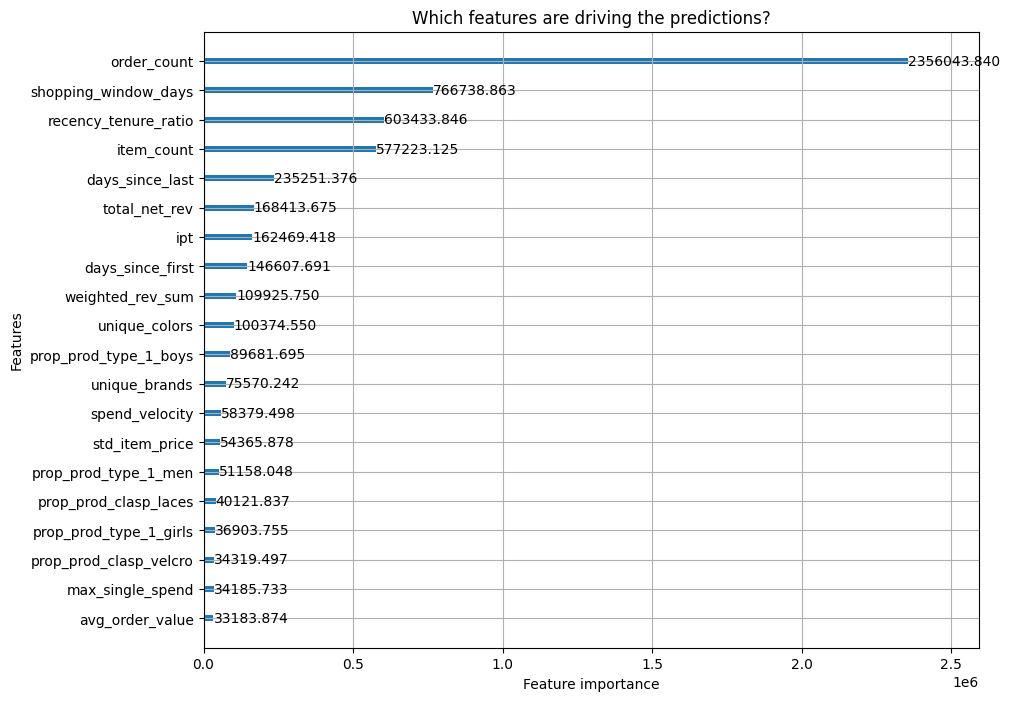

In [21]:
import matplotlib.pyplot as plt

lgb.plot_importance(model_prod, max_num_features=20, importance_type='gain', figsize=(10,8))
plt.title("Which features are driving the predictions?")
plt.show()

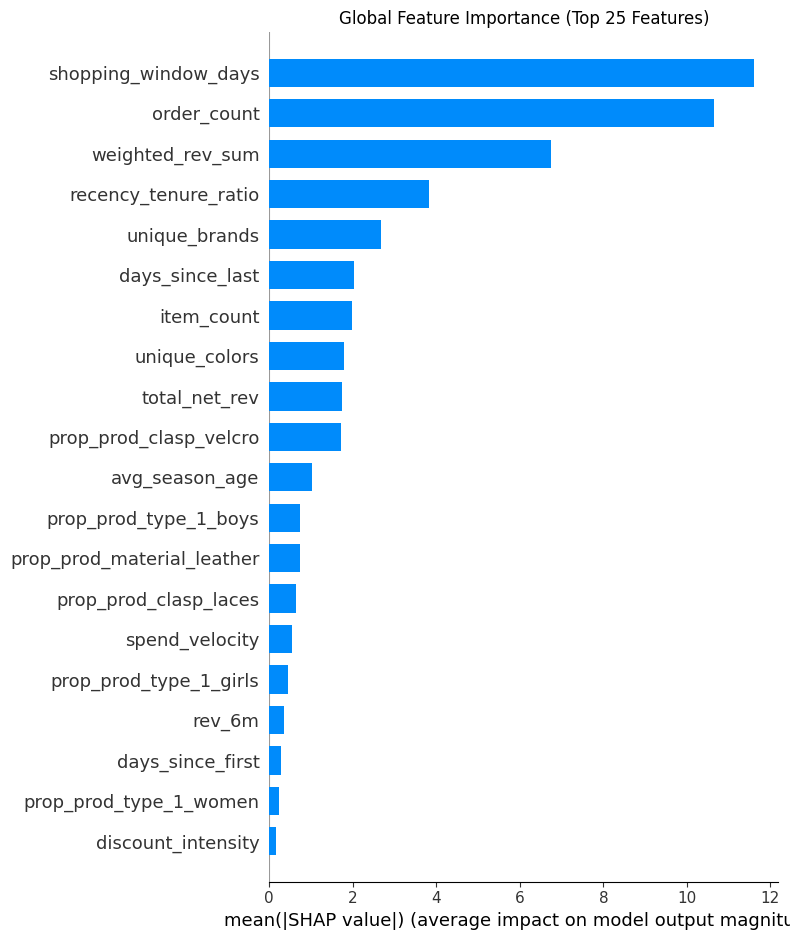

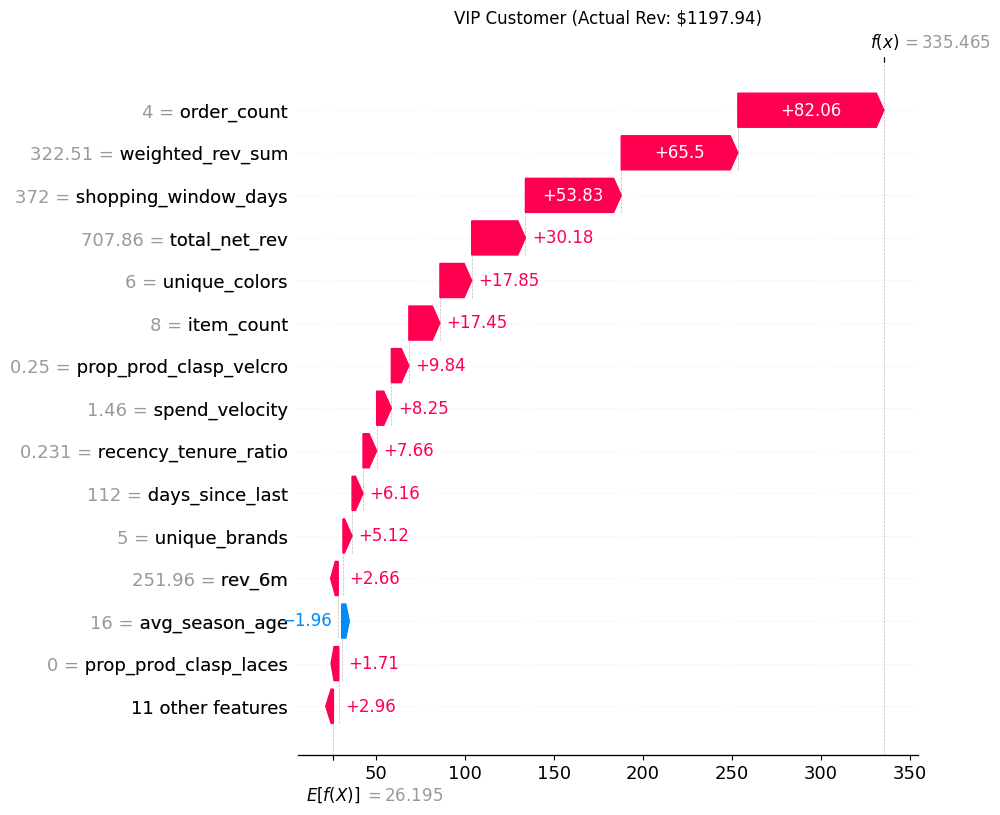

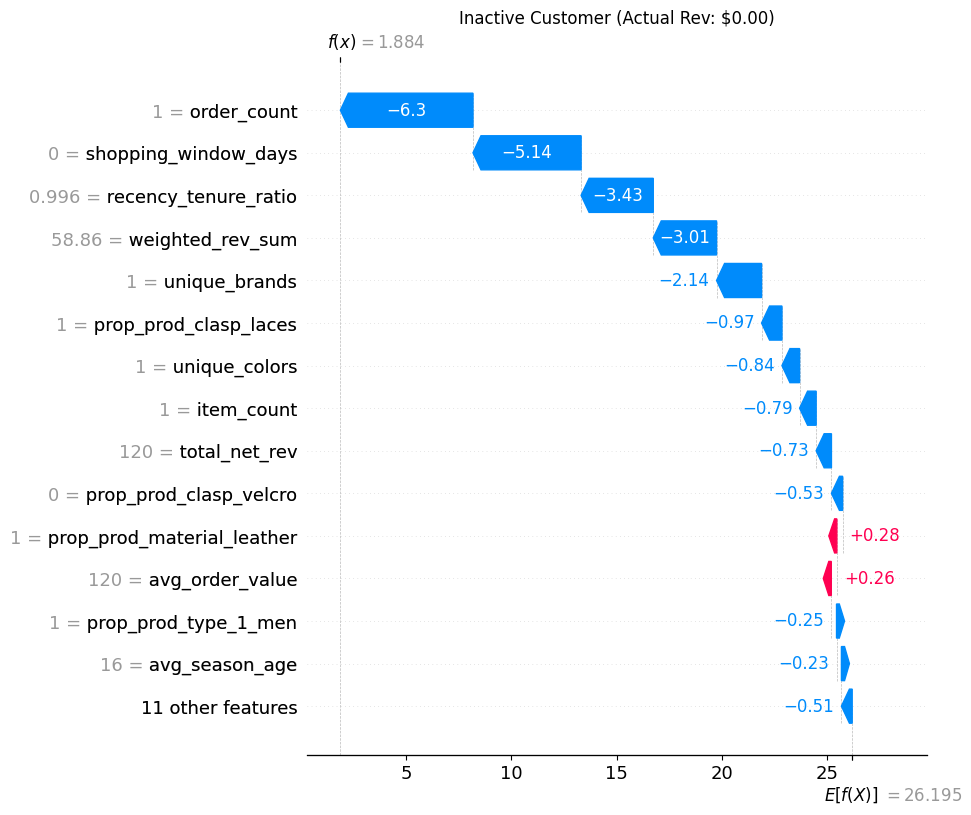

In [35]:
import shap

#Top 25 Features by Importance
feature_names_all = model_prod.feature_name_
importances = model_prod.feature_importances_
feat_imp_df = pd.DataFrame({'name': feature_names_all, 'imp': importances})
top_25_names = feat_imp_df.sort_values('imp', ascending=False).head(25)['name'].tolist()

top_25_indices = [feature_names_all.index(name) for name in top_25_names]
shap_values_top = shap_values[:, top_25_indices]

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_top, X_full[top_25_names], plot_type="bar", show=False)
plt.title("Top 25 Features")
plt.tight_layout()
plt.show()

#VIP Customer 
vip_idx = y_full.values.argmax()
exp_vip = shap.Explanation(
    values=shap_values_top[vip_idx],           
    base_values=explainer.expected_value,      
    data=X_full[top_25_names].iloc[vip_idx].values,                  
    feature_names=top_25_names                 
)
plt.figure()
shap.waterfall_plot(exp_vip, max_display=15, show=False)
plt.title(f"VIP Customer (Actual Rev: ${y_full.iloc[vip_idx]:.2f})")
plt.show()

#Inactive Customer 
inactive_idx = (y_full.values == 0).nonzero()[0][0]
exp_inactive = shap.Explanation(
    values=shap_values_top[inactive_idx],
    base_values=explainer.expected_value,
    data=X_full[top_25_names].iloc[inactive_idx].values,
    feature_names=top_25_names
)
plt.figure()
shap.waterfall_plot(exp_inactive, max_display=15, show=False)
plt.title("Inactive Customer (Actual Rev: $0.00)")
plt.show()

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0


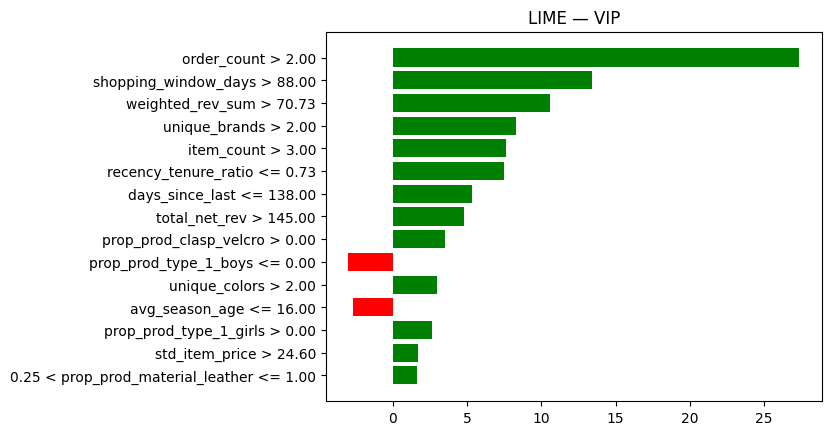

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0


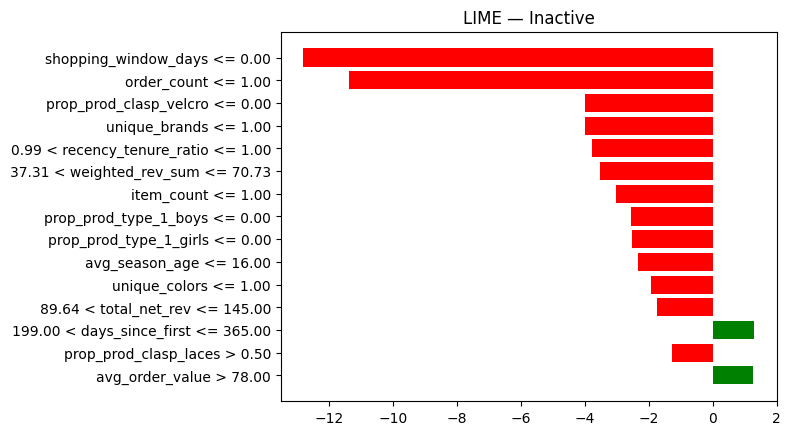

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0


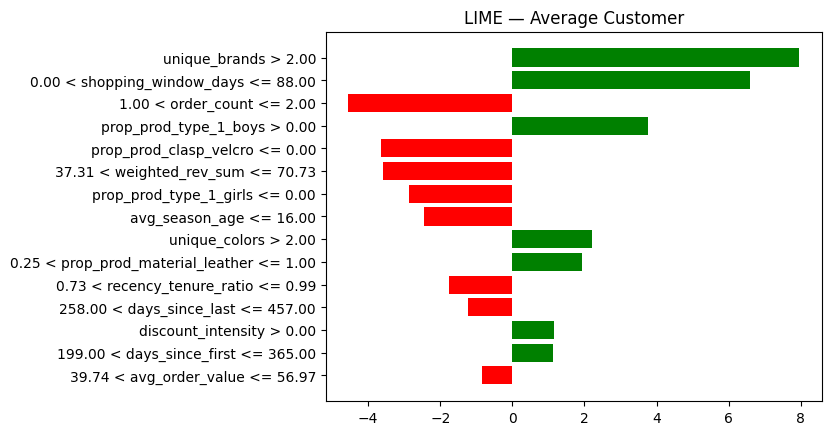

In [37]:
import lime
import lime.lime_tabular

importances = model_prod.feature_importances_
feature_names_all = model_prod.feature_name_
feat_imp_df = pd.DataFrame({'name': feature_names_all, 'imp': importances})
top_25_names = feat_imp_df.sort_values('imp', ascending=False).head(25)['name'].tolist()

X_full_top25 = X_full[top_25_names]

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_full_top25.values,
    feature_names=top_25_names,
    mode="regression",
    random_state=42
)

def predict_fn_top25(X_array_25):
    X_full_template = pd.DataFrame(0, index=range(len(X_array_25)), columns=feature_names_all)
    X_df_25 = pd.DataFrame(X_array_25, columns=top_25_names)
    for col in top_25_names:
        X_full_template[col] = X_df_25[col].values
        
    preds = model_prod.predict(X_full_template)
    return np.maximum(0, preds)

# VIP 
vip_idx = y_full.values.argmax()
exp_vip = explainer_lime.explain_instance(
    data_row=X_full_top25.iloc[vip_idx].values,
    predict_fn=predict_fn_top25,
    num_features=15
)
fig_vip = exp_vip.as_pyplot_figure()
plt.title("LIME — VIP")
plt.show()

# Inactive 
inactive_idx = (y_full.values == 0).nonzero()[0][0]
exp_inactive = explainer_lime.explain_instance(
    data_row=X_full_top25.iloc[inactive_idx].values,
    predict_fn=predict_fn_top25,
    num_features=15
)
fig_inactive = exp_inactive.as_pyplot_figure()
plt.title("LIME — Inactive")
plt.show()

# Average 
avg_idx = (np.abs(y_full.values - y_full.mean())).argmin()
exp_avg = explainer_lime.explain_instance(
    data_row=X_full_top25.iloc[avg_idx].values,
    predict_fn=predict_fn_top25,
    num_features=15
)
fig_avg = exp_avg.as_pyplot_figure()
plt.title("LIME — Average Customer")
plt.show()

In [102]:
X_test_final = test_customers[['cust_id']].merge(X_loaded, on='cust_id', how='left')
X_test_final = clean_feature_names(X_test_final)

print(f"NaNs in Test {X_test_final.isna().sum().sum()}")

test_ids = X_test_final['cust_id']
X_test_input = X_test_final.drop(columns=['cust_id'])
X_test_input = X_test_input.loc[:, ~X_test_input.columns.duplicated()].copy()
X_test_input = X_test_input.reindex(columns=model_prod.feature_name_, fill_value=0)

test_preds = model_prod.predict(X_test_input)
final_predictions = np.maximum(0, test_preds)

submission = pd.DataFrame({
    'cust_id': test_ids,
    'revenue_2018_2019': final_predictions
})

submission.to_csv('lightgbm_full_feature.csv', index=False)

NaNs in Test 0
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
